# Análise de Recursos Humanos - HR Dataset

Este projeto analisa os dados de Recursos Humanos de uma empresa fictícia, com o objetivo de entender o perfil dos colaboradores, identificar padrões salariais, avaliar desempenho, satisfação e engajamento, e investigar os principais fatores associados ao turnover.

A base contém informações de 311 colaboradores, incluindo dados demográficos, salariais, de performance e de absenteísmo, coletados entre 2006 e 2018.

## Importação das bibliotecas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Configuração visual

In [2]:
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelsize"] = 11
paleta = "viridis"


## Carregamento da base

In [3]:
df = pd.read_csv("HRDataset_v14.csv")
df.columns = df.columns.str.strip()
df.head()

,Employee_Name,EmpID,MarriedID,MaritalStatusID,GenderID,EmpStatusID,DeptID,PerfScoreID,FromDiversityJobFairID,Salary,...,ManagerName,ManagerID,RecruitmentSource,PerformanceScore,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,LastPerformanceReview_Date,DaysLateLast30,Absences
0,"Adinolfi, Wilson K",10026,0,0,1,1,5,4,0,62506,...,Michael Albert,22.0,LinkedIn,Exceeds,4.60,5,0,1/17/2019,0,1
1,"Ait Sidi, Karthikeyan",10084,1,1,1,5,3,3,0,104437,...,Simon Roup,4.0,Indeed,Fully Meets,4.96,3,6,2/24/2016,0,17
2,"Akinkuolie, Sarah",10196,1,1,0,5,5,3,0,64955,...,Kissy Sullivan,20.0,LinkedIn,Fully Meets,3.02,3,0,5/15/2012,0,3
3,"Alagbe,Trina",10088,1,1,0,1,5,3,0,64991,...,Elijiah Gray,16.0,Indeed,Fully Meets,4.84,5,0,1/3/2019,0,15
4,"Anderson, Carol",10069,0,2,0,5,5,3,0,50825,...,Webster Butler,39.0,Google Search,Fully Meets,5.00,4,0,2/1/2016,0,2


In [4]:
df.shape

(311, 36)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 311 entries, 0 to 310
Data columns (total 36 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Employee_Name               311 non-null    str    
 1   EmpID                       311 non-null    int64  
 2   MarriedID                   311 non-null    int64  
 3   MaritalStatusID             311 non-null    int64  
 4   GenderID                    311 non-null    int64  
 5   EmpStatusID                 311 non-null    int64  
 6   DeptID                      311 non-null    int64  
 7   PerfScoreID                 311 non-null    int64  
 8   FromDiversityJobFairID      311 non-null    int64  
 9   Salary                      311 non-null    int64  
 10  Termd                       311 non-null    int64  
 11  PositionID                  311 non-null    int64  
 12  Position                    311 non-null    str    
 13  State                       311 non-null    st

In [6]:
df.dtypes.value_counts()

str        18
int64      16
float64     2
Name: count, dtype: int64

## Limpeza dos dados

Antes de iniciar a limpeza, é importante entender a estrutura dos dados nulos, dos tipos de coluna e de possíveis inconsistências.

### Valores ausentes

In [7]:
df.isnull().sum()[df.isnull().sum() > 0]

DateofTermination    207
ManagerID              8
dtype: int64

As únicas colunas com valores ausentes são `DateofTermination` e `ManagerID`.

`DateofTermination` está vazia justamente para os colaboradores que ainda estão ativos na empresa, então esses valores não devem ser removidos nem preenchidos artificialmente, pois representam uma informação válida.

`ManagerID` está vazia para colaboradores do alto escalão, que não possuem um gestor direto cadastrado na base.

In [8]:
df[df["ManagerID"].isnull()][["Employee_Name", "Position", "Department"]]

,Employee_Name,Position,Department
19,"Becker, Scott",Production Technician I,Production
30,"Buccheri, Joseph",Production Technician II,Production
44,"Chang, Donovan E",Production Technician I,Production
88,"Fancett, Nicole",Production Technician II,Production
135,"Hutter, Rosalie",Production Technician II,Production
177,"Manchester, Robyn",Production Technician II,Production
232,"Rivera, Haley",Production Technician I,Production
251,"Sewkumar, Nori",Production Technician I,Production


### Linhas duplicadas

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df["EmpID"].duplicated().sum()

np.int64(0)

Não há linhas duplicadas nem IDs de funcionário repetidos.

### Espaços em branco em colunas de texto

Algumas colunas de texto, como `Department` e `Sex`, possuem espaços extras que podem prejudicar agrupamentos e contagens.

In [11]:
colunas_texto = df.select_dtypes(include="object").columns
df[colunas_texto] = df[colunas_texto].apply(lambda x: x.str.strip())

/tmp/ipykernel_594/2213347130.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  colunas_texto = df.select_dtypes(include="object").columns


### Registros inconsistentes

Ao inspecionar os nomes dos colaboradores, há um registro com o nome "Voldemort, Lord", claramente um dado fictício inserido na base, sem relação com os demais funcionários. Esse registro será removido por se tratar de uma inconsistência evidente.

In [12]:
df = df[df["Employee_Name"] != "Voldemort, Lord"].reset_index(drop=True)
df.shape

(310, 36)

### Conversão das colunas de data

As colunas `DOB`, `DateofHire`, `DateofTermination` e `LastPerformanceReview_Date` estão como texto e precisam ser convertidas para o formato de data.

A coluna `DOB` usa ano com dois dígitos, o que faz o pandas interpretar datas como 2068 em vez de 1968. Essa distorção é corrigida subtraindo cem anos das datas de nascimento que ficaram no futuro.

In [13]:
df["DOB"] = pd.to_datetime(df["DOB"], format="%m/%d/%y")
df.loc[df["DOB"].dt.year > 2026, "DOB"] -= pd.DateOffset(years=100)

df["DateofHire"] = pd.to_datetime(df["DateofHire"], format="%m/%d/%Y")
df["DateofTermination"] = pd.to_datetime(df["DateofTermination"], format="%m/%d/%Y")
df["LastPerformanceReview_Date"] = pd.to_datetime(df["LastPerformanceReview_Date"], format="%m/%d/%Y")

df[["DOB", "DateofHire", "DateofTermination", "LastPerformanceReview_Date"]].dtypes

DOB                           datetime64[us]
DateofHire                    datetime64[us]
DateofTermination             datetime64[us]
LastPerformanceReview_Date    datetime64[us]
dtype: object

### Outliers evidentes

In [14]:
df[["Salary", "EngagementSurvey", "EmpSatisfaction", "Absences", "DaysLateLast30"]].describe()

,Salary,EngagementSurvey,EmpSatisfaction,Absences,DaysLateLast30
count,310.000000,310.000000,310.000000,310.000000,310.000000
mean,68875.593548,4.109290,3.893548,10.241935,0.416129
std,25066.636338,0.791115,0.909296,5.861634,1.296397
min,45046.000000,1.120000,1.000000,1.000000,0.000000
25%,55463.250000,3.690000,3.000000,5.000000,0.000000
50%,62734.500000,4.280000,4.000000,10.000000,0.000000
75%,71939.500000,4.700000,5.000000,15.000000,0.000000
max,250000.000000,5.000000,5.000000,20.000000,6.000000


A coluna `Salary` apresenta uma amplitude grande, mas os valores são compatíveis com diferentes cargos da empresa, de Production Technician a Diretores e Presidente. Não há valores negativos ou absurdos, então nenhum registro será removido por esse critério.

As colunas `EngagementSurvey` e `EmpSatisfaction` estão dentro das escalas esperadas. `Absences` e `DaysLateLast30` possuem valores altos em alguns casos, mas são plausíveis para um período de meses e serão tratados como informação legítima, não como erro.

## Análise inicial

Com a base limpa, seguem as informações estruturais atualizadas.

In [15]:
df.shape

(310, 36)

In [16]:
df.describe()

,EmpID,MarriedID,MaritalStatusID,GenderID,EmpStatusID,DeptID,PerfScoreID,FromDiversityJobFairID,Salary,Termd,...,DOB,DateofHire,DateofTermination,ManagerID,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,LastPerformanceReview_Date,DaysLateLast30,Absences
count,310.000000,310.000000,310.000000,310.000000,310.000000,310.000000,310.000000,310.000000,310.000000,310.000000,...,310,310,103,302.000000,310.000000,310.000000,310.000000,310,310.000000,310.000000
mean,10156.122581,0.396774,0.809677,0.432258,2.387097,4.616129,2.977419,0.093548,68875.593548,0.332258,...,1979-01-28 13:46:50.322580,2013-02-01 13:23:36.774193,2015-06-08 11:39:01.747572,14.605960,4.109290,3.893548,1.200000,2017-09-11 13:23:36.774193,0.416129,10.241935
min,10001.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,45046.000000,0.000000,...,1951-01-02 00:00:00,2006-01-09 00:00:00,2010-08-30 00:00:00,1.000000,1.120000,1.000000,0.000000,2010-07-14 00:00:00,0.000000,1.000000
25%,10078.250000,0.000000,0.000000,0.000000,1.000000,5.000000,3.000000,0.000000,55463.250000,0.000000,...,1973-11-30 12:00:00,2011-07-11 00:00:00,2014-01-10 00:00:00,10.000000,3.690000,3.000000,0.000000,2016-03-12 18:00:00,0.000000,5.000000
50%,10156.500000,0.000000,1.000000,0.000000,1.000000,5.000000,3.000000,0.000000,62734.500000,0.000000,...,1980-09-12 12:00:00,2013-02-03 12:00:00,2015-09-15 00:00:00,15.000000,4.280000,4.000000,0.000000,2019-01-16 00:00:00,0.000000,10.000000
75%,10233.750000,1.000000,1.000000,1.000000,5.000000,5.000000,3.000000,0.000000,71939.500000,1.000000,...,1986-05-17 18:00:00,2014-09-10 06:00:00,2016-09-05 12:00:00,19.000000,4.700000,5.000000,0.000000,2019-02-04 00:00:00,0.000000,15.000000
max,10311.000000,1.000000,4.000000,1.000000,5.000000,6.000000,4.000000,1.000000,250000.000000,1.000000,...,1992-08-17 00:00:00,2018-07-09 00:00:00,2018-11-10 00:00:00,39.000000,5.000000,5.000000,8.000000,2019-02-28 00:00:00,6.000000,20.000000
std,90.041546,0.490019,0.944702,0.496191,1.794948,1.081350,0.588019,0.291670,25066.636338,0.471785,...,NaN,NaN,NaN,8.068665,0.791115,0.909296,2.330049,NaN,1.296397,5.861634


In [17]:
df.isnull().sum()[df.isnull().sum() > 0]

DateofTermination    207
ManagerID              8
dtype: int64

## KPIs gerais

A coluna `Idade` é calculada a partir da data de nascimento e a coluna `TempoEmpresaAnos` considera a data de desligamento para quem já saiu da empresa, ou a data atual para quem está ativo.

In [18]:
data_referencia = pd.Timestamp("2026-06-27")

df["Idade"] = ((data_referencia - df["DOB"]).dt.days // 365)
df["DataReferenciaTempo"] = df["DateofTermination"].fillna(data_referencia)
df["TempoEmpresaAnos"] = ((df["DataReferenciaTempo"] - df["DateofHire"]).dt.days / 365).round(1)

In [19]:
total_funcionarios = df["EmpID"].count()
ativos = (df["Termd"] == 0).sum()
desligados = (df["Termd"] == 1).sum()
salario_medio = df["Salary"].mean()
salario_mediano = df["Salary"].median()
tempo_medio_empresa = df["TempoEmpresaAnos"].mean()
idade_media = df["Idade"].mean()
satisfacao_media = df["EmpSatisfaction"].mean()
engajamento_medio = df["EngagementSurvey"].mean()

kpis = pd.Series({
    "Total de funcionários": total_funcionarios,
    "Funcionários ativos": ativos,
    "Funcionários desligados": desligados,
    "Salário médio": round(salario_medio, 2),
    "Salário mediano": salario_mediano,
    "Tempo médio de empresa (anos)": round(tempo_medio_empresa, 1),
    "Idade média": round(idade_media, 1),
    "Satisfação média": round(satisfacao_media, 2),
    "Engajamento médio": round(engajamento_medio, 2)
})
kpis

Total de funcionários              310.00
Funcionários ativos                207.00
Funcionários desligados            103.00
Salário médio                    68875.59
Salário mediano                  62734.50
Tempo médio de empresa (anos)        9.70
Idade média                         46.90
Satisfação média                     3.89
Engajamento médio                    4.11
dtype: float64

In [20]:
df["PerformanceScore"].value_counts(normalize=True).round(3) * 100

PerformanceScore
Fully Meets          78.1
Exceeds              11.9
Needs Improvement     5.8
PIP                   4.2
Name: proportion, dtype: float64

A empresa conta com 310 funcionários cadastrados, dos quais 207 estão ativos e 103 já foram desligados, o que representa uma rotatividade histórica relevante. O salário médio fica em torno de 69 mil dólares, com mediana próxima da média, indicando uma distribuição salarial relativamente equilibrada.

Em relação à performance, a maior parte do quadro está classificada como "Fully Meets", o que é esperado em uma distribuição saudável de avaliações. O tempo médio de empresa de quase 10 anos sugere um quadro de funcionários com bom tempo de casa.

## Análises demográficas

### Distribuição por sexo

In [21]:
df["Sex"].value_counts()

Sex
F    176
M    134
Name: count, dtype: int64

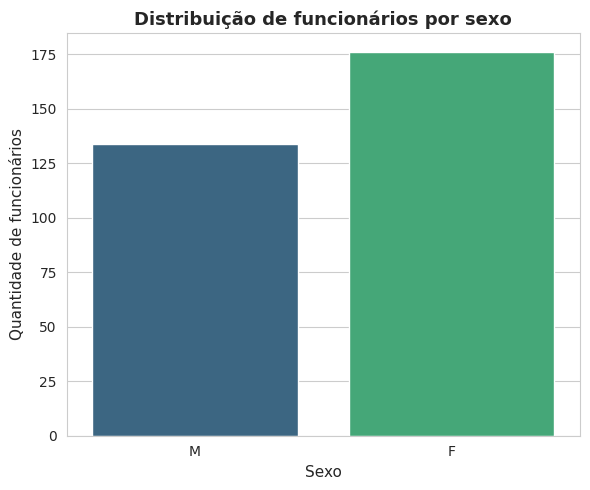

In [22]:
plt.figure(figsize=(6, 5))
sns.countplot(data=df, x="Sex", hue="Sex", palette=paleta, legend=False)
plt.title("Distribuição de funcionários por sexo")
plt.xlabel("Sexo")
plt.ylabel("Quantidade de funcionários")
plt.tight_layout()
plt.show()

### Distribuição por estado civil

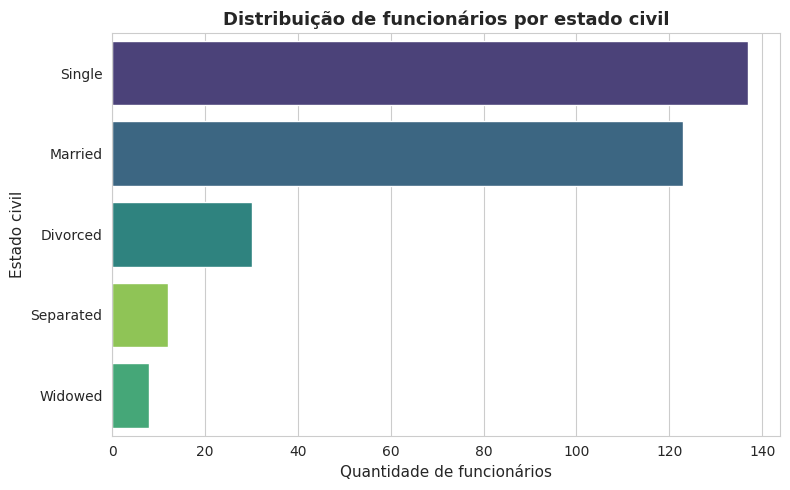

In [23]:
plt.figure(figsize=(8, 5))
ordem_estado_civil = df["MaritalDesc"].value_counts().index
sns.countplot(data=df, y="MaritalDesc", order=ordem_estado_civil, hue="MaritalDesc", palette=paleta, legend=False)
plt.title("Distribuição de funcionários por estado civil")
plt.xlabel("Quantidade de funcionários")
plt.ylabel("Estado civil")
plt.tight_layout()
plt.show()

### Distribuição por departamento

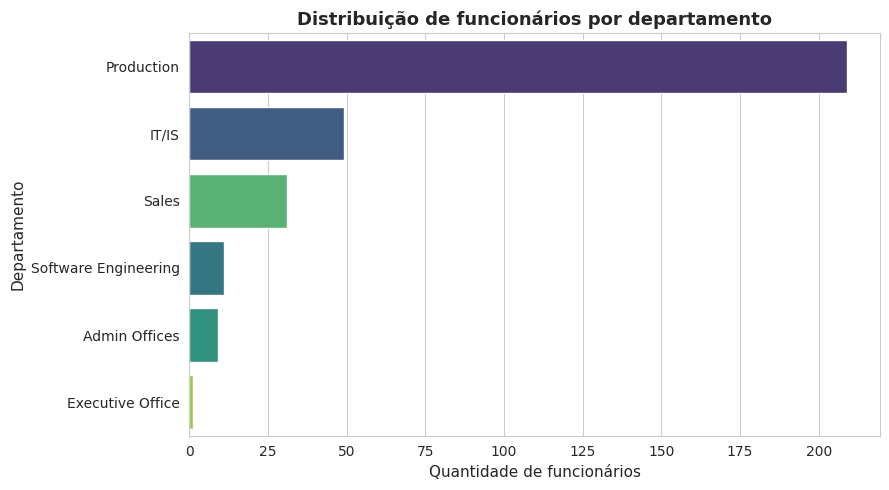

In [24]:
plt.figure(figsize=(9, 5))
ordem_departamento = df["Department"].value_counts().index
sns.countplot(data=df, y="Department", order=ordem_departamento, hue="Department", palette=paleta, legend=False)
plt.title("Distribuição de funcionários por departamento")
plt.xlabel("Quantidade de funcionários")
plt.ylabel("Departamento")
plt.tight_layout()
plt.show()

### Distribuição por cargo

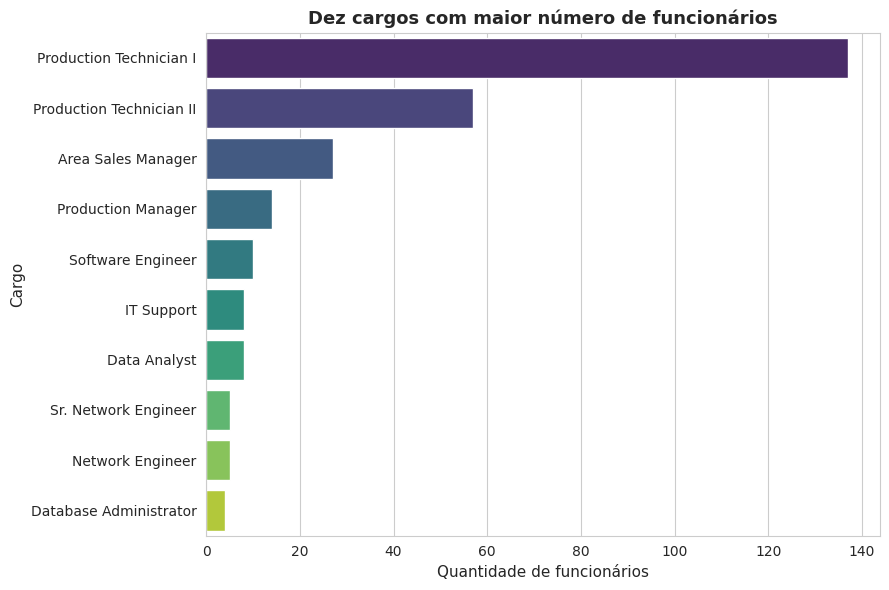

In [25]:
top_cargos = df["Position"].value_counts().head(10)

plt.figure(figsize=(9, 6))
sns.barplot(x=top_cargos.values, y=top_cargos.index, hue=top_cargos.index, palette=paleta, legend=False)
plt.title("Dez cargos com maior número de funcionários")
plt.xlabel("Quantidade de funcionários")
plt.ylabel("Cargo")
plt.tight_layout()
plt.show()

### Distribuição por estado

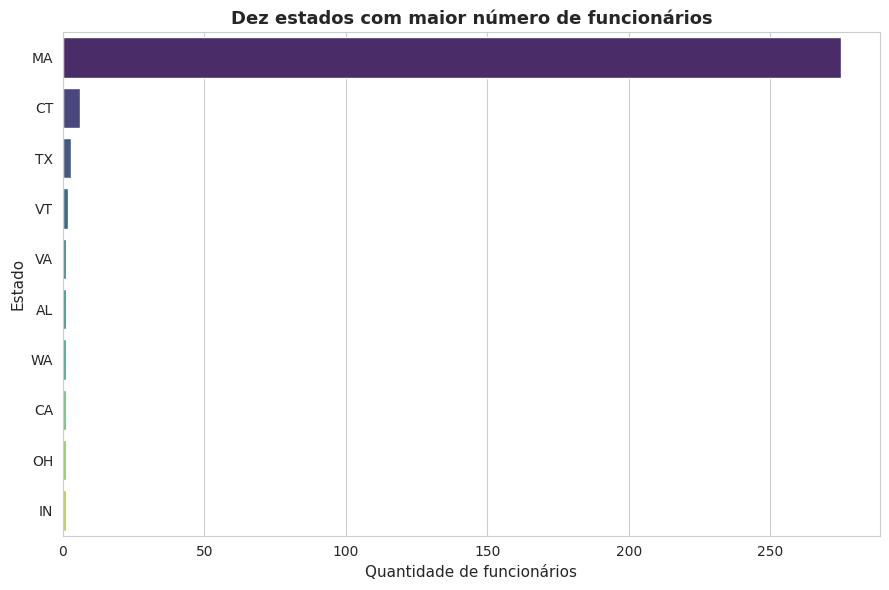

In [26]:
top_estados = df["State"].value_counts().head(10)

plt.figure(figsize=(9, 6))
sns.barplot(x=top_estados.values, y=top_estados.index, hue=top_estados.index, palette=paleta, legend=False)
plt.title("Dez estados com maior número de funcionários")
plt.xlabel("Quantidade de funcionários")
plt.ylabel("Estado")
plt.tight_layout()
plt.show()

### Distribuição por raça

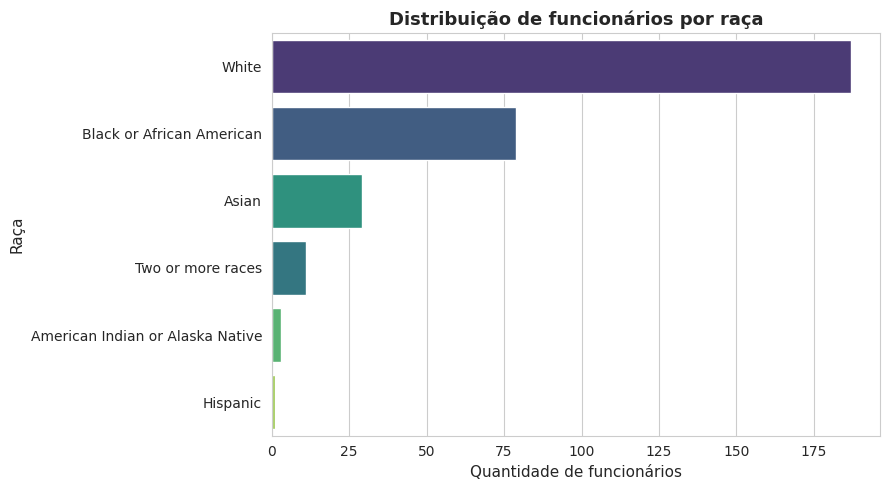

In [27]:
plt.figure(figsize=(9, 5))
ordem_raca = df["RaceDesc"].value_counts().index
sns.countplot(data=df, y="RaceDesc", order=ordem_raca, hue="RaceDesc", palette=paleta, legend=False)
plt.title("Distribuição de funcionários por raça")
plt.xlabel("Quantidade de funcionários")
plt.ylabel("Raça")
plt.tight_layout()
plt.show()

### Distribuição por idade

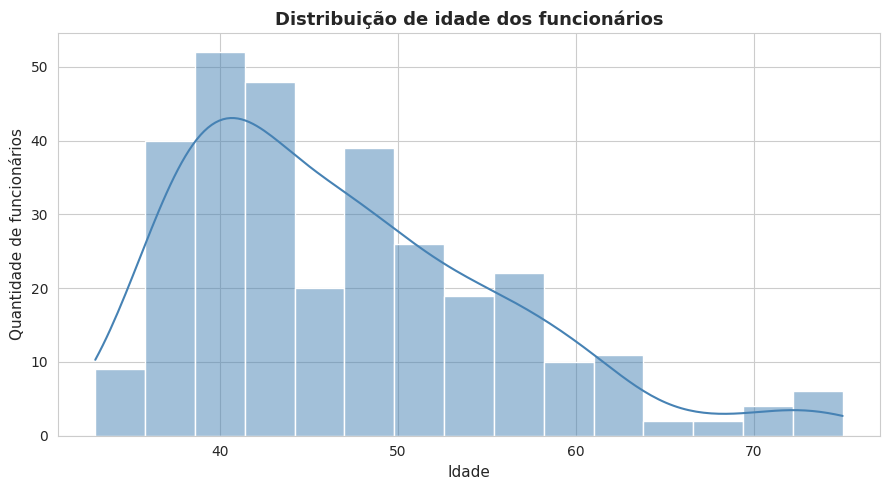

In [28]:
plt.figure(figsize=(9, 5))
sns.histplot(data=df, x="Idade", bins=15, kde=True, color="steelblue")
plt.title("Distribuição de idade dos funcionários")
plt.xlabel("Idade")
plt.ylabel("Quantidade de funcionários")
plt.tight_layout()
plt.show()

A empresa apresenta um quadro majoritariamente concentrado em Massachusetts, departamento de Produção e cargos operacionais, o que é coerente com o porte e o tipo de operação retratados na base.

A distribuição por sexo é relativamente equilibrada, com leve predominância de mulheres, enquanto o estado civil mais comum é "Married". Em termos de raça, a maioria dos funcionários se declara branca, seguida por negros ou afro-americanos.

A idade dos funcionários está concentrada entre 40 e 55 anos, com uma distribuição que não apresenta assimetrias extremas, sugerindo um quadro de funcionários maduro e experiente.

## Análise salarial

### Salário por departamento

In [29]:
salario_departamento = df.groupby("Department")["Salary"].agg(["mean", "median", "count"]).sort_values("mean", ascending=False)
salario_departamento

,mean,median,count
Department,,,
Executive Office,250000.000000,250000.0,1
IT/IS,96719.040816,92328.0,49
Software Engineering,94989.454545,95660.0,11
Admin Offices,71791.888889,63003.0,9
Sales,69061.258065,65310.0,31
Production,59953.545455,59472.0,209


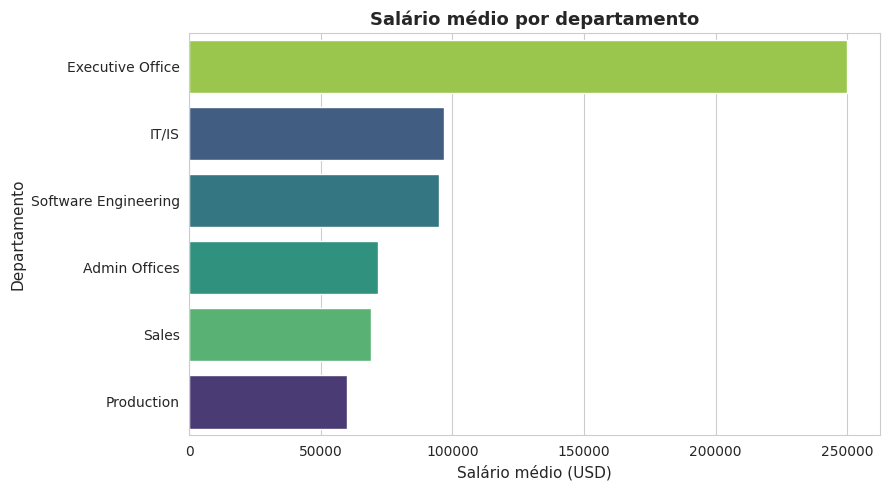

In [30]:
plt.figure(figsize=(9, 5))
ordem_salario_dept = salario_departamento.index
sns.barplot(data=df, x="Salary", y="Department", order=ordem_salario_dept, hue="Department", palette=paleta, legend=False, errorbar=None)
plt.title("Salário médio por departamento")
plt.xlabel("Salário médio (USD)")
plt.ylabel("Departamento")
plt.tight_layout()
plt.show()

### Salário por cargo

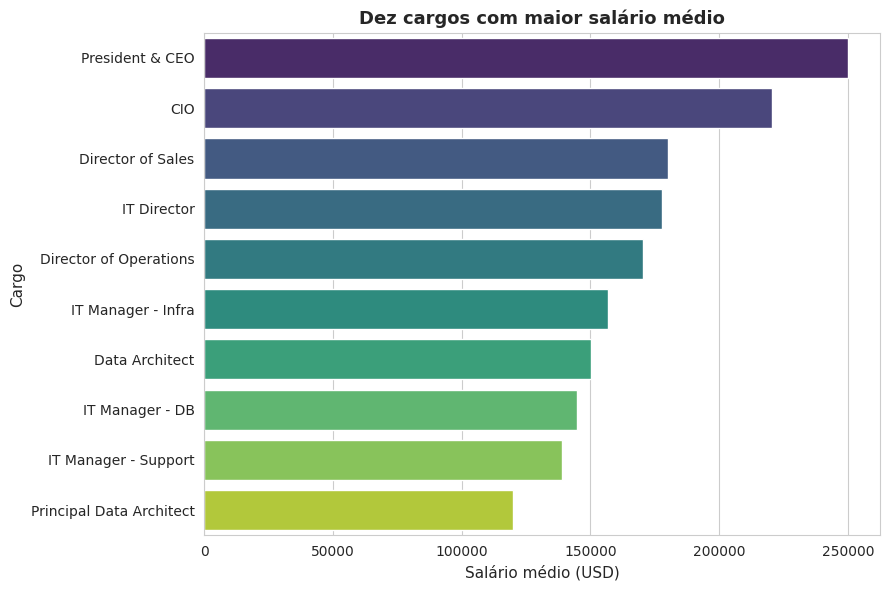

In [31]:
salario_cargo = df.groupby("Position")["Salary"].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(9, 6))
sns.barplot(x=salario_cargo.values, y=salario_cargo.index, hue=salario_cargo.index, palette=paleta, legend=False)
plt.title("Dez cargos com maior salário médio")
plt.xlabel("Salário médio (USD)")
plt.ylabel("Cargo")
plt.tight_layout()
plt.show()

### Distribuição salarial

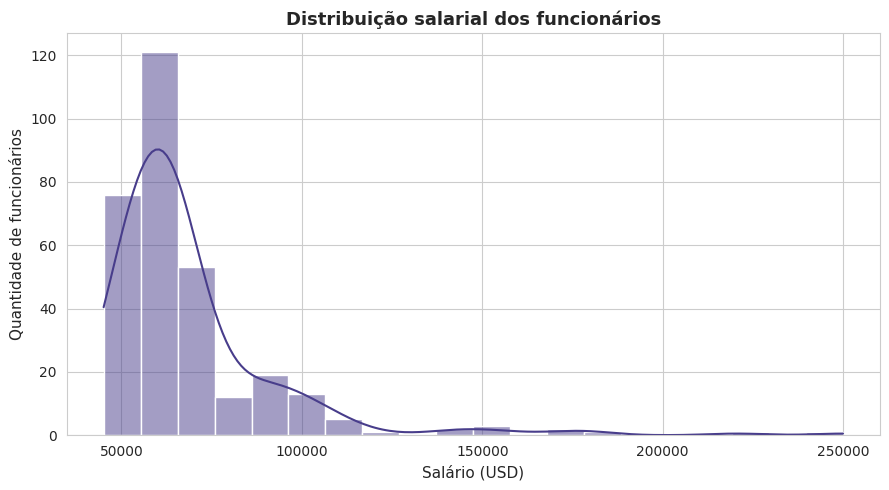

In [32]:
plt.figure(figsize=(9, 5))
sns.histplot(data=df, x="Salary", bins=20, kde=True, color="darkslateblue")
plt.title("Distribuição salarial dos funcionários")
plt.xlabel("Salário (USD)")
plt.ylabel("Quantidade de funcionários")
plt.tight_layout()
plt.show()

### Boxplot de salários por departamento

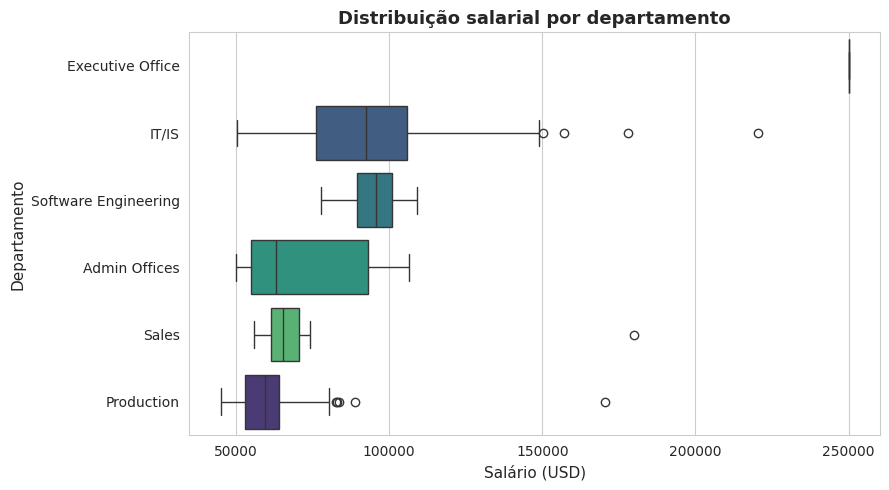

In [33]:
plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x="Salary", y="Department", order=ordem_salario_dept, hue="Department", palette=paleta, legend=False)
plt.title("Distribuição salarial por departamento")
plt.xlabel("Salário (USD)")
plt.ylabel("Departamento")
plt.tight_layout()
plt.show()

### Funcionários mais bem pagos e menos remunerados

In [34]:
df[["Employee_Name", "Position", "Department", "Salary"]].sort_values("Salary", ascending=False).head(10)

,Employee_Name,Position,Department,Salary
150,"King, Janet",President & CEO,Executive Office,250000
307,"Zamora, Jennifer",CIO,IT/IS,220450
131,"Houlihan, Debra",Director of Sales,Sales,180000
96,"Foss, Jason",IT Director,IT/IS,178000
55,"Corleone, Vito",Director of Operations,Production,170500
190,"Monroe, Peter",IT Manager - Infra,IT/IS,157000
240,"Roper, Katie",Data Architect,IT/IS,150290
244,"Ruiz, Ricardo",IT Manager - DB,IT/IS,148999
243,"Roup,Simon",IT Manager - DB,IT/IS,140920
76,"Dougall, Eric",IT Manager - Support,IT/IS,138888


In [35]:
df[["Employee_Name", "Position", "Department", "Salary"]].sort_values("Salary").head(10)

,Employee_Name,Position,Department,Salary
309,"Zima, Colleen",Production Technician I,Production,45046
140,"Jacobi, Hannah",Production Technician I,Production,45069
231,"Rhoads, Thomas",Production Technician I,Production,45115
176,"Mahoney, Lauren",Production Technician I,Production,45395
152,"Kirill, Alexandra",Production Technician I,Production,45433
216,"Perry, Shakira",Production Technician I,Production,45998
159,"Langton, Enrico",Production Technician I,Production,46120
74,"Dobrin, Denisa S",Production Technician I,Production,46335
247,"Sadki, Nore",Production Technician I,Production,46428
226,"Purinton, Janine",Production Technician I,Production,46430


### Salário por gênero

In [36]:
salario_genero = df.groupby("Sex")["Salary"].agg(["mean", "median", "count"])
salario_genero

,mean,median,count
Sex,,,
F,67786.727273,62066.5,176
M,70305.746269,63322.0,134


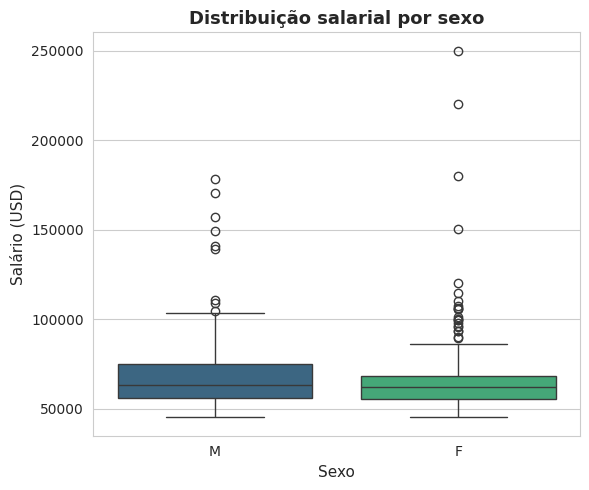

In [37]:
plt.figure(figsize=(6, 5))
sns.boxplot(data=df, x="Sex", y="Salary", hue="Sex", palette=paleta, legend=False)
plt.title("Distribuição salarial por sexo")
plt.xlabel("Sexo")
plt.ylabel("Salário (USD)")
plt.tight_layout()
plt.show()

### Salário por desempenho

In [38]:
salario_performance = df.groupby("PerformanceScore")["Salary"].mean().sort_values(ascending=False)
salario_performance

PerformanceScore
Exceeds              77144.864865
Needs Improvement    68407.555556
Fully Meets          68178.157025
PIP                  58971.076923
Name: Salary, dtype: float64

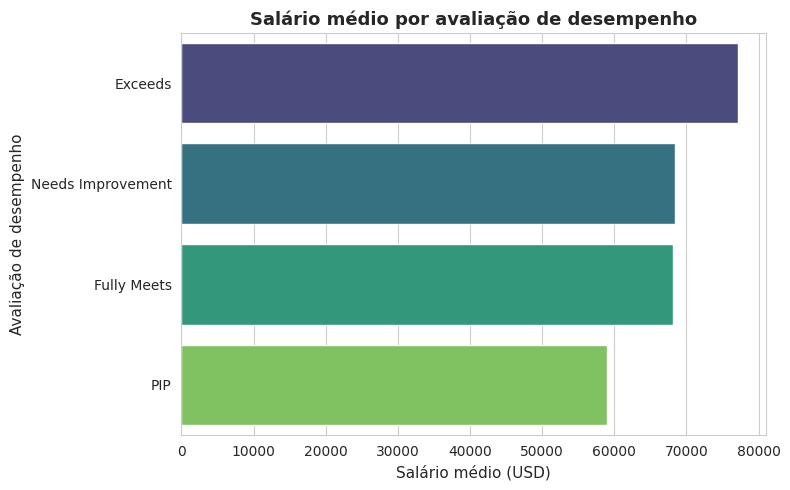

In [39]:
plt.figure(figsize=(8, 5))
sns.barplot(x=salario_performance.values, y=salario_performance.index, hue=salario_performance.index, palette=paleta, legend=False)
plt.title("Salário médio por avaliação de desempenho")
plt.xlabel("Salário médio (USD)")
plt.ylabel("Avaliação de desempenho")
plt.tight_layout()
plt.show()

O departamento de Executive Office concentra os maiores salários médios, o que é esperado dado o nível hierárquico dos cargos. Em contrapartida, Production apresenta os salários mais baixos, refletindo a natureza operacional das funções.

A diferença salarial entre homens e mulheres é pequena, sem indícios de uma disparidade relevante entre os sexos nesta base. Já o salário médio não varia de forma expressiva entre as categorias de performance, o que sugere que a remuneração está mais associada ao cargo e ao departamento do que à avaliação de desempenho recente.

## Performance

### Distribuição das avaliações

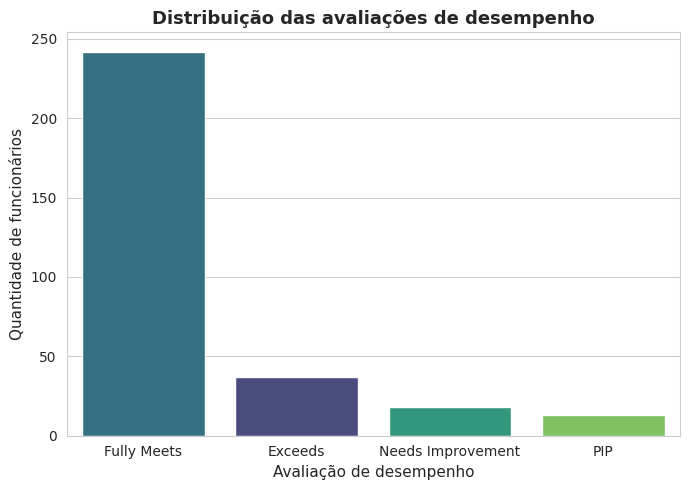

In [40]:
plt.figure(figsize=(7, 5))
ordem_performance = df["PerformanceScore"].value_counts().index
sns.countplot(data=df, x="PerformanceScore", order=ordem_performance, hue="PerformanceScore", palette=paleta, legend=False)
plt.title("Distribuição das avaliações de desempenho")
plt.xlabel("Avaliação de desempenho")
plt.ylabel("Quantidade de funcionários")
plt.tight_layout()
plt.show()

### Performance por departamento

In [41]:
performance_departamento = df.groupby(["Department", "PerformanceScore"]).size().unstack(fill_value=0)
performance_departamento

PerformanceScore,Exceeds,Fully Meets,Needs Improvement,PIP
Department,,,,
Admin Offices,0,9,0,0
Executive Office,0,1,0,0
IT/IS,6,41,1,1
Production,27,159,15,8
Sales,2,24,1,4
Software Engineering,2,8,1,0


### Performance por gestor

In [42]:
performance_gestor = df.groupby("ManagerName")["PerfScoreID"].mean().sort_values(ascending=False).head(10)
performance_gestor

ManagerName
Eric Dougall          3.250000
Jennifer Zamora       3.142857
Simon Roup            3.125000
Alex Sweetwater       3.111111
Janet King            3.105263
Kelley Spirea         3.090909
Ketsia Liebig         3.047619
Brandon R. LeBlanc    3.000000
Board of Directors    3.000000
Webster Butler        3.000000
Name: PerfScoreID, dtype: float64

### Performance por cargo

In [43]:
performance_cargo = df.groupby("Position")["PerfScoreID"].mean().sort_values(ascending=False).head(10)
performance_cargo

Position
CIO                       4.000
IT Director               4.000
Director of Operations    4.000
IT Manager - Support      4.000
Data Analyst              3.250
IT Support                3.125
Software Engineer         3.100
Director of Sales         3.000
BI Developer              3.000
Database Administrator    3.000
Name: PerfScoreID, dtype: float64

### Funcionários com melhor e pior avaliação

In [44]:
df[df["PerformanceScore"] == "Exceeds"][["Employee_Name", "Position", "Department", "PerformanceScore"]]

,Employee_Name,Position,Department,PerformanceScore
0,"Adinolfi, Wilson K",Production Technician I,Production,Exceeds
5,"Anderson, Linda",Production Technician I,Production,Exceeds
12,"Barbossa, Hector",Data Analyst,IT/IS,Exceeds
16,"Beak, Kimberly",Production Technician II,Production,Exceeds
22,"Billis, Helen",Production Technician I,Production,Exceeds
36,"Candie, Calvin",Production Manager,Production,Exceeds
51,"Clukey, Elijian",Production Technician I,Production,Exceeds
55,"Corleone, Vito",Director of Operations,Production,Exceeds
76,"Dougall, Eric",IT Manager - Support,IT/IS,Exceeds
77,"Driver, Elle",Area Sales Manager,Sales,Exceeds


In [45]:
df[df["PerformanceScore"] == "PIP"][["Employee_Name", "Position", "Department", "PerformanceScore"]]

,Employee_Name,Position,Department,PerformanceScore
67,"Delarge, Alex",Area Sales Manager,Sales,PIP
69,"Desimone, Carl",Production Technician I,Production,PIP
72,"Dietrich, Jenna",Area Sales Manager,Sales,PIP
83,"Erilus, Angela",Production Technician II,Production,PIP
90,"Fernandes, Nilson",Production Technician I,Production,PIP
91,"Fett, Boba",Network Engineer,IT/IS,PIP
95,"Forrest, Alex",Area Sales Manager,Sales,PIP
112,"Gonzalez, Juan",Production Technician II,Production,PIP
188,"Miller, Ned",Production Technician II,Production,PIP
205,"O'hare, Lynn",Production Technician I,Production,PIP


A maior parte dos funcionários está classificada como "Fully Meets", o que indica uma avaliação concentrada em torno da expectativa, com poucos casos extremos de "Exceeds" ou "PIP". Essa concentração é comum em processos de avaliação de desempenho bem calibrados.

Ao olhar por departamento, não há um setor com avaliações sistematicamente piores, o que sugere que os casos de baixa performance estão distribuídos de forma pontual, e não concentrados em uma área específica da empresa.

## Satisfação

### Satisfação por departamento

In [46]:
satisfacao_departamento = df.groupby("Department")["EmpSatisfaction"].mean().sort_values(ascending=False)
satisfacao_departamento

Department
Software Engineering    4.090909
Sales                   4.032258
IT/IS                   3.979592
Production              3.861244
Admin Offices           3.555556
Executive Office        3.000000
Name: EmpSatisfaction, dtype: float64

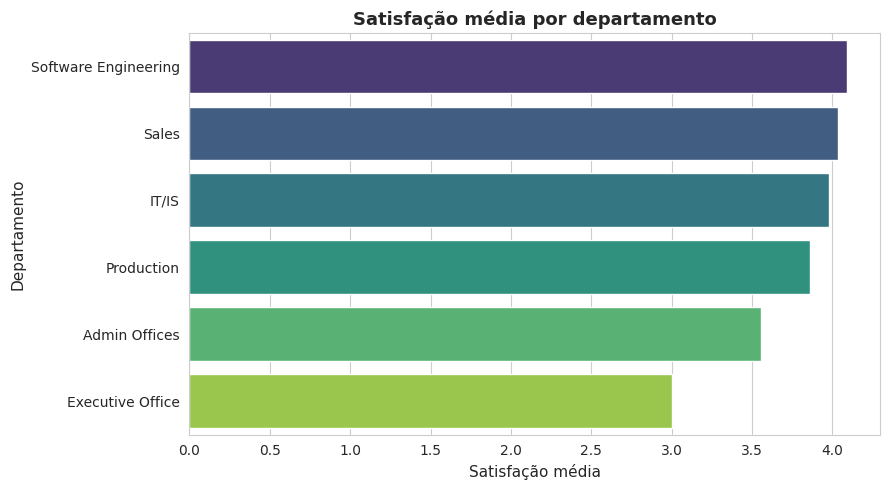

In [47]:
plt.figure(figsize=(9, 5))
sns.barplot(x=satisfacao_departamento.values, y=satisfacao_departamento.index, hue=satisfacao_departamento.index, palette=paleta, legend=False)
plt.title("Satisfação média por departamento")
plt.xlabel("Satisfação média")
plt.ylabel("Departamento")
plt.tight_layout()
plt.show()

### Satisfação por cargo

In [48]:
satisfacao_cargo = df.groupby("Position")["EmpSatisfaction"].mean().sort_values(ascending=False).head(10)
satisfacao_cargo

Position
BI Director               5.000000
CIO                       5.000000
Director of Operations    5.000000
Enterprise Architect      5.000000
IT Director               5.000000
IT Manager - Support      5.000000
IT Manager - DB           4.500000
Sales Manager             4.333333
BI Developer              4.250000
Sr. Network Engineer      4.200000
Name: EmpSatisfaction, dtype: float64

### Satisfação por gestor

In [49]:
satisfacao_gestor = df.groupby("ManagerName")["EmpSatisfaction"].mean().sort_values(ascending=False).head(10)
satisfacao_gestor

ManagerName
Debra Houlihan      4.333333
Jennifer Zamora     4.285714
Alex Sweetwater     4.222222
Ketsia Liebig       4.095238
Lynn Daneault       4.076923
Webster Butler      4.047619
Michael Albert      4.045455
Brian Champaigne    4.000000
Elijiah Gray        3.954545
David Stanley       3.952381
Name: EmpSatisfaction, dtype: float64

### Relação entre satisfação e desempenho

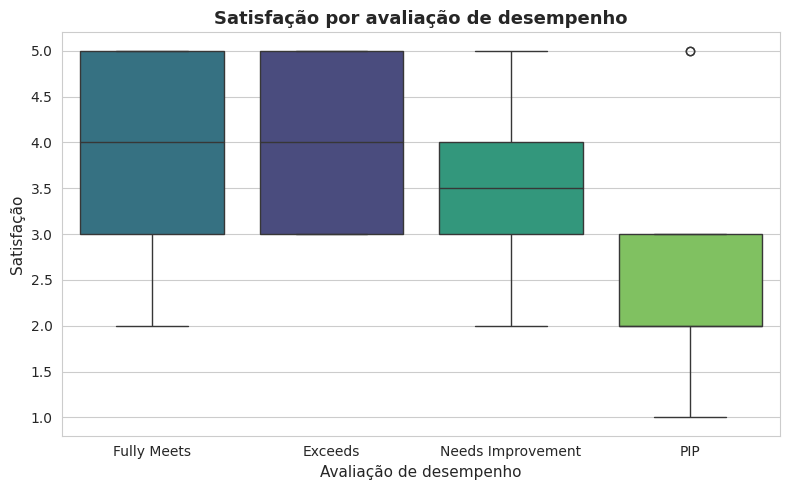

In [50]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="PerformanceScore", y="EmpSatisfaction", order=ordem_performance, hue="PerformanceScore", palette=paleta, legend=False)
plt.title("Satisfação por avaliação de desempenho")
plt.xlabel("Avaliação de desempenho")
plt.ylabel("Satisfação")
plt.tight_layout()
plt.show()

Os níveis de satisfação estão bem próximos entre os departamentos, sem grandes destaques positivos ou negativos. Isso indica que a percepção dos funcionários em relação ao ambiente de trabalho é relativamente homogênea ao longo da empresa.

Quando comparada à performance, a satisfação não apresenta uma relação muito clara, o que sugere que outros fatores, além da nota de desempenho, influenciam a forma como o funcionário avalia sua satisfação no trabalho.

## Engajamento

### Engajamento por departamento

In [51]:
engajamento_departamento = df.groupby("Department")["EngagementSurvey"].mean().sort_values(ascending=False)
engajamento_departamento

Department
Executive Office        4.830000
Admin Offices           4.393333
IT/IS                   4.150408
Production              4.129569
Software Engineering    4.061818
Sales                   3.818710
Name: EngagementSurvey, dtype: float64

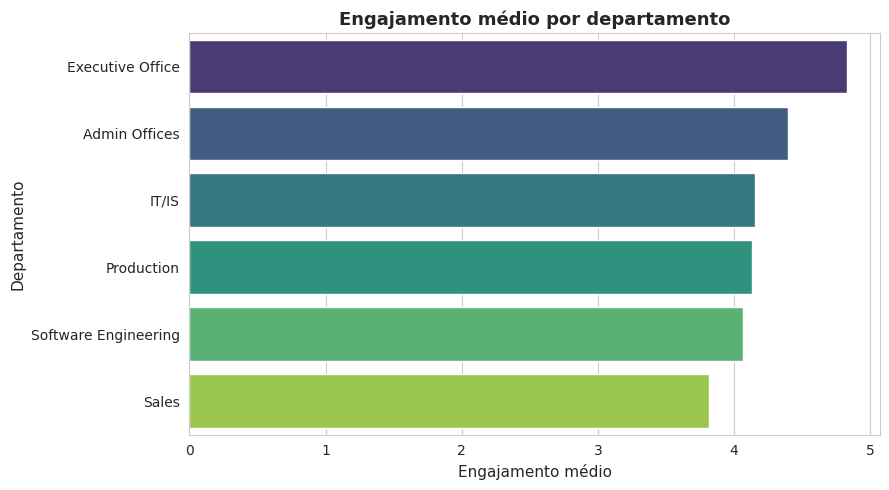

In [52]:
plt.figure(figsize=(9, 5))
sns.barplot(x=engajamento_departamento.values, y=engajamento_departamento.index, hue=engajamento_departamento.index, palette=paleta, legend=False)
plt.title("Engajamento médio por departamento")
plt.xlabel("Engajamento médio")
plt.ylabel("Departamento")
plt.tight_layout()
plt.show()

### Engajamento por gestor

In [53]:
engajamento_gestor = df.groupby("ManagerName")["EngagementSurvey"].mean().sort_values(ascending=False).head(10)
engajamento_gestor

ManagerName
Board of Directors    4.915000
Eric Dougall          4.585000
Kelley Spirea         4.484545
Brandon R. LeBlanc    4.348571
Webster Butler        4.325238
Simon Roup            4.218750
Janet King            4.182105
David Stanley         4.150952
Alex Sweetwater       4.076667
Elijiah Gray          4.074545
Name: EngagementSurvey, dtype: float64

### Engajamento por desempenho

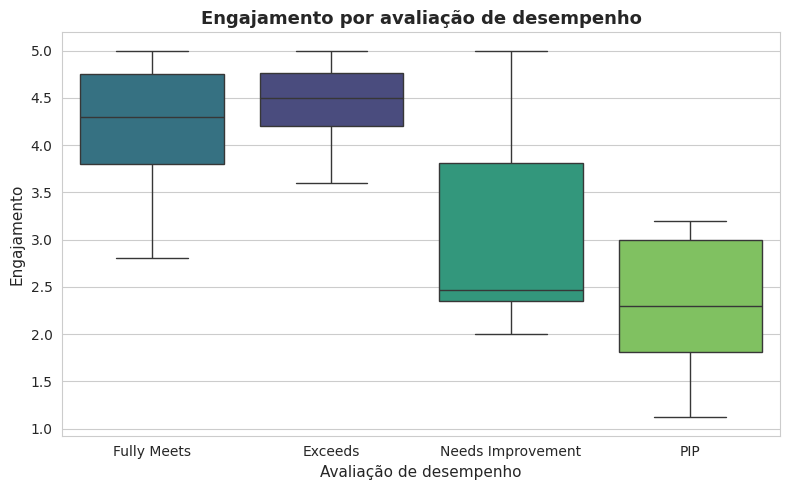

In [54]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="PerformanceScore", y="EngagementSurvey", order=ordem_performance, hue="PerformanceScore", palette=paleta, legend=False)
plt.title("Engajamento por avaliação de desempenho")
plt.xlabel("Avaliação de desempenho")
plt.ylabel("Engajamento")
plt.tight_layout()
plt.show()

O engajamento segue um padrão parecido com o da satisfação, com pouca variação entre departamentos. Isso reforça a ideia de que o clima organizacional é razoavelmente uniforme entre as diferentes áreas da empresa.

Funcionários com performance "PIP" tendem a apresentar engajamento mais baixo e mais disperso, o que é um sinal coerente, já que a falta de engajamento costuma impactar diretamente os resultados de desempenho.

## Absenteísmo

Para medir atraso e faltas por grupo, utiliza-se a média, já que a contagem simples de funcionários não representa a intensidade do absenteísmo.

### Dias de atraso e faltas - visão geral

In [55]:
df[["DaysLateLast30", "Absences"]].describe()

,DaysLateLast30,Absences
count,310.000000,310.000000
mean,0.416129,10.241935
std,1.296397,5.861634
min,0.000000,1.000000
25%,0.000000,5.000000
50%,0.000000,10.000000
75%,0.000000,15.000000
max,6.000000,20.000000


### Departamentos com maior atraso médio

In [56]:
atraso_departamento = df.groupby("Department")["DaysLateLast30"].mean().sort_values(ascending=False)
atraso_departamento

Department
Sales                   0.645161
Production              0.468900
Software Engineering    0.363636
IT/IS                   0.142857
Executive Office        0.000000
Admin Offices           0.000000
Name: DaysLateLast30, dtype: float64

### Departamentos com maior número médio de faltas

In [57]:
faltas_departamento = df.groupby("Department")["Absences"].mean().sort_values(ascending=False)
faltas_departamento

Department
Sales                   11.548387
IT/IS                   10.469388
Production              10.143541
Executive Office        10.000000
Software Engineering     8.727273
Admin Offices            8.666667
Name: Absences, dtype: float64

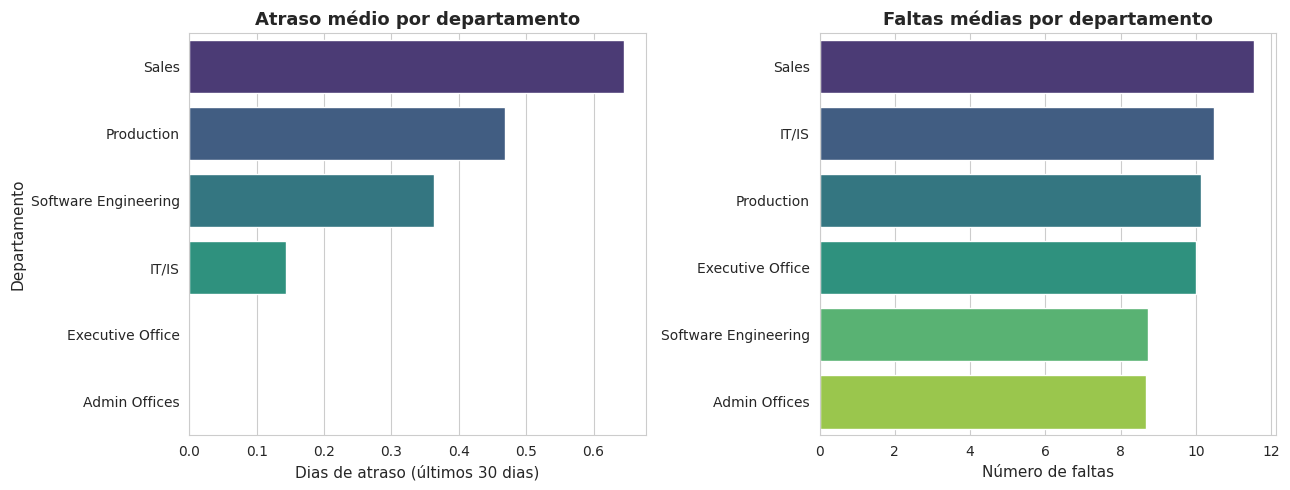

In [58]:
fig, eixos = plt.subplots(1, 2, figsize=(13, 5))

sns.barplot(x=atraso_departamento.values, y=atraso_departamento.index, hue=atraso_departamento.index, palette=paleta, legend=False, ax=eixos[0])
eixos[0].set_title("Atraso médio por departamento")
eixos[0].set_xlabel("Dias de atraso (últimos 30 dias)")
eixos[0].set_ylabel("Departamento")

sns.barplot(x=faltas_departamento.values, y=faltas_departamento.index, hue=faltas_departamento.index, palette=paleta, legend=False, ax=eixos[1])
eixos[1].set_title("Faltas médias por departamento")
eixos[1].set_xlabel("Número de faltas")
eixos[1].set_ylabel("")

plt.tight_layout()
plt.show()

### Funcionários com mais atrasos e mais faltas

In [59]:
df[["Employee_Name", "Department", "DaysLateLast30"]].sort_values("DaysLateLast30", ascending=False).head(10)

,Employee_Name,Department,DaysLateLast30
90,"Fernandes, Nilson",Production,6
296,"Wallace, Theresa",Production,6
205,"O'hare, Lynn",Production,6
263,"Sparks, Taylor",Production,6
67,"Delarge, Alex",Sales,6
188,"Miller, Ned",Production,6
215,"Pelletier, Ermine",Production,5
85,"Evensen, April",Production,5
84,"Estremera, Miguel",Production,5
306,"Ybarra, Catherine",Production,5


In [60]:
df[["Employee_Name", "Department", "Absences"]].sort_values("Absences", ascending=False).head(10)

,Employee_Name,Department,Absences
263,"Sparks, Taylor",Production,20
256,"Sloan, Constance",Production,20
109,"Goeth, Amon",IT/IS,20
114,"Good, Susan",Production,20
121,"Guilianno, Mike",Sales,20
161,"Latif, Mohammed",Production,20
107,"Givens, Myriam",Sales,20
183,"Mckenna, Sandy",Production,20
93,"Fitzpatrick, Michael J",Production,20
15,"Bates, Norman",Production,20


Sales é o departamento com maior atraso médio nos últimos 30 dias, enquanto Admin Offices e Executive Office não registram atrasos no período analisado. Em relação a faltas, os valores médios são parecidos entre os departamentos, sem um destaque muito acentuado.

O absenteísmo, de forma geral, não parece estar concentrado em um único setor, o que indica que pode ser mais um comportamento individual do que um problema estrutural de algum departamento específico.

## Turnover

O turnover é calculado como a proporção de funcionários desligados (`Termd igual a 1`) em relação ao total de funcionários cadastrados na base.

In [61]:
turnover_geral = (df["Termd"].sum() / len(df)) * 100
round(turnover_geral, 2)

np.float64(33.23)

### Turnover por departamento

In [62]:
turnover_departamento = (df.groupby("Department")["Termd"].mean() * 100).sort_values(ascending=False)
turnover_departamento

Department
Production              39.712919
Software Engineering    36.363636
Admin Offices           22.222222
IT/IS                   18.367347
Sales                   16.129032
Executive Office         0.000000
Name: Termd, dtype: float64

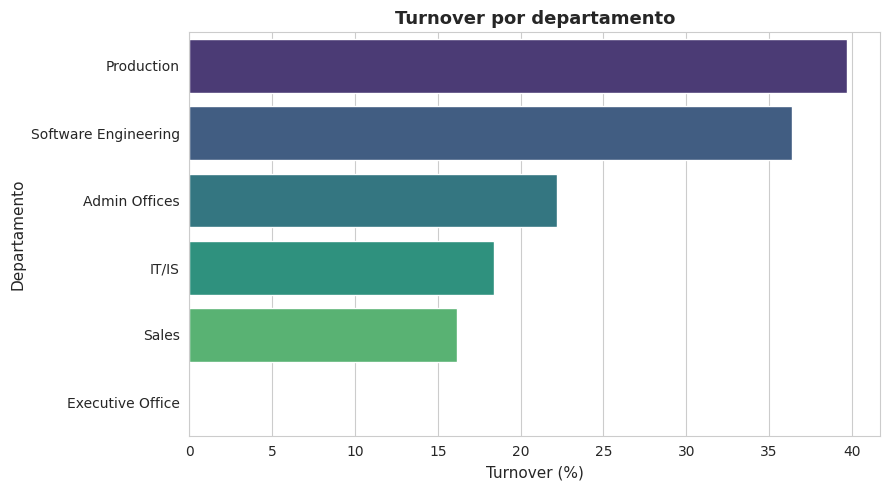

In [63]:
plt.figure(figsize=(9, 5))
sns.barplot(x=turnover_departamento.values, y=turnover_departamento.index, hue=turnover_departamento.index, palette=paleta, legend=False)
plt.title("Turnover por departamento")
plt.xlabel("Turnover (%)")
plt.ylabel("Departamento")
plt.tight_layout()
plt.show()

### Turnover por cargo

In [64]:
turnover_cargo = (df.groupby("Position")["Termd"].mean() * 100).sort_values(ascending=False)
turnover_cargo.head(10)

Position
Enterprise Architect        100.000000
Principal Data Architect    100.000000
Administrative Assistant     66.666667
IT Manager - DB              50.000000
Database Administrator       50.000000
Sr. DBA                      50.000000
Production Technician II     45.614035
Software Engineer            40.000000
Production Technician I      37.956204
Production Manager           35.714286
Name: Termd, dtype: float64

### Turnover por gestor

In [65]:
turnover_gestor = (df.groupby("ManagerName")["Termd"].mean() * 100).sort_values(ascending=False)
turnover_gestor.head(10)

ManagerName
Amy Dunn              61.904762
Webster Butler        61.904762
Kissy Sullivan        54.545455
Simon Roup            43.750000
Michael Albert        40.909091
Elijiah Gray          36.363636
Debra Houlihan        33.333333
Alex Sweetwater       33.333333
Janet King            31.578947
Brandon R. LeBlanc    28.571429
Name: Termd, dtype: float64

O turnover geral da empresa é de aproximadamente 33%, um valor alto, considerando que a base reúne todo o histórico de admissões e desligamentos. Production e Software Engineering são os departamentos com maior rotatividade, enquanto Executive Office não registra nenhum desligamento.

Esse padrão é coerente com o perfil de cada área: cargos operacionais e técnicos tendem a apresentar maior rotatividade do que posições de liderança, que normalmente possuem processos seletivos mais rigorosos e maior estabilidade.

## Tempo de empresa

In [66]:
df["TempoEmpresaAnos"].mean().round(1)

np.float64(9.7)

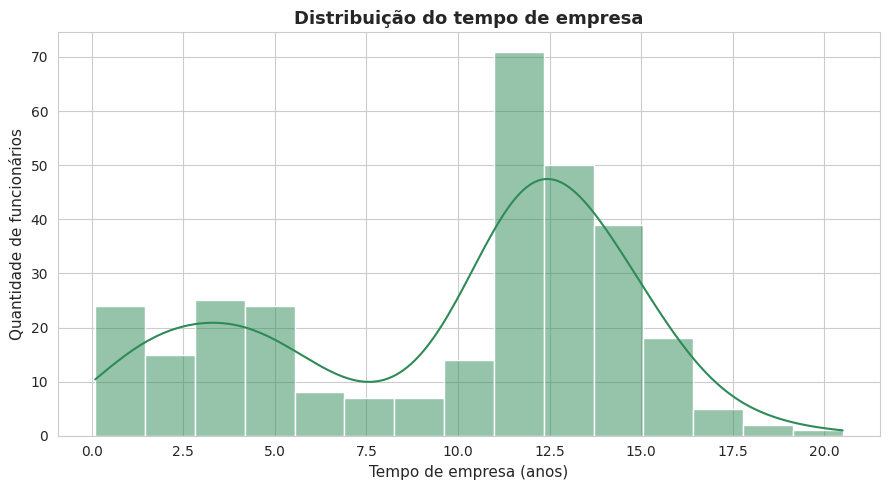

In [67]:
plt.figure(figsize=(9, 5))
sns.histplot(data=df, x="TempoEmpresaAnos", bins=15, kde=True, color="seagreen")
plt.title("Distribuição do tempo de empresa")
plt.xlabel("Tempo de empresa (anos)")
plt.ylabel("Quantidade de funcionários")
plt.tight_layout()
plt.show()

### Funcionários com maior tempo de empresa

In [68]:
df[["Employee_Name", "Position", "DateofHire", "TempoEmpresaAnos"]].sort_values("TempoEmpresaAnos", ascending=False).head(10)

,Employee_Name,Position,DateofHire,TempoEmpresaAnos
282,"Torrence, Jack",Area Sales Manager,2006-01-09,20.5
222,"Pitt, Brad",Production Technician I,2007-11-05,18.7
3,"Alagbe,Trina",Production Technician I,2008-01-07,18.5
29,"Brown, Mia",Accountant I,2008-10-27,17.7
271,"Sullivan, Kissy",Production Manager,2009-01-08,17.5
55,"Corleone, Vito",Director of Operations,2009-01-05,17.5
97,"Foster-Baker, Amy",Sr. Accountant,2009-01-05,17.5
8,"Bachiochi, Linda",Production Technician I,2009-07-06,17.0
79,"Dunne, Amy",Production Technician I,2010-04-26,16.2
99,"Galia, Lisa",IT Support,2010-05-01,16.2


### Funcionários recém contratados

In [69]:
df[["Employee_Name", "Position", "DateofHire", "TempoEmpresaAnos"]].sort_values("TempoEmpresaAnos").head(10)

,Employee_Name,Position,DateofHire,TempoEmpresaAnos
233,"Roberson, May",Production Technician II,2011-09-26,0.1
108,"Goble, Taisha",Database Administrator,2015-02-16,0.1
132,"Howard, Estelle",Administrative Assistant,2015-02-16,0.2
295,"Wallace, Courtney E",Production Manager,2011-09-26,0.3
129,"Homberger, Adrienne J",Production Technician II,2011-08-15,0.6
234,"Robertson, Peter",Production Technician II,2011-07-05,0.6
226,"Purinton, Janine",Production Technician I,2012-09-24,0.7
249,"Salter, Jason",Data Analyst,2015-01-05,0.8
27,"Bozzi, Charles",Production Manager,2013-09-30,0.9
161,"Latif, Mohammed",Production Technician II,2012-04-02,1.0


O tempo médio de empresa gira em torno de 9 anos e meio, o que reforça a leitura de um quadro de funcionários relativamente maduro. A distribuição mostra uma concentração entre 5 e 13 anos de empresa, com poucos casos de tempo muito curto ou muito longo.

Os funcionários mais antigos foram contratados ainda nos primeiros anos da base de dados, enquanto os mais recentes ingressaram próximo à última data de contratação registrada, o que é esperado em qualquer organização com fluxo contínuo de admissões.

## Projetos especiais

A coluna `SpecialProjectsCount` indica quantos projetos especiais cada funcionário participou. Para esta análise, os funcionários são divididos entre quem participou de pelo menos um projeto especial e quem não participou.

In [70]:
df["ParticipouProjetoEspecial"] = df["SpecialProjectsCount"] > 0

projetos_especiais = df.groupby("ParticipouProjetoEspecial").agg(
    SalarioMedio=("Salary", "mean"),
    EngajamentoMedio=("EngagementSurvey", "mean"),
    SatisfacaoMedia=("EmpSatisfaction", "mean")
).round(2)

projetos_especiais

,SalarioMedio,EngajamentoMedio,SatisfacaoMedia
ParticipouProjetoEspecial,,,
False,62143.51,4.10,3.89
True,92389.09,4.15,3.91


In [71]:
performance_projetos = df.groupby("ParticipouProjetoEspecial")["PerformanceScore"].value_counts(normalize=True).unstack().round(3) * 100
performance_projetos

PerformanceScore,Exceeds,Fully Meets,Needs Improvement,PIP
ParticipouProjetoEspecial,,,,
False,12.0,76.8,6.6,4.6
True,11.6,82.6,2.9,2.9


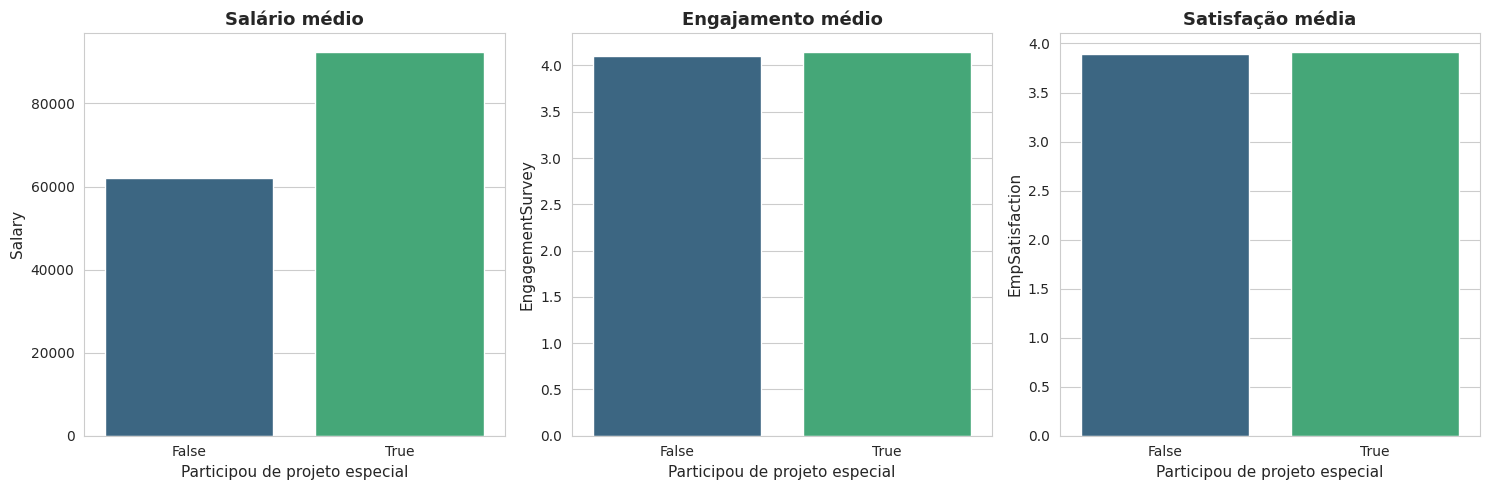

In [72]:
fig, eixos = plt.subplots(1, 3, figsize=(15, 5))

sns.barplot(data=df, x="ParticipouProjetoEspecial", y="Salary", hue="ParticipouProjetoEspecial", palette=paleta, legend=False, errorbar=None, ax=eixos[0])
eixos[0].set_title("Salário médio")
eixos[0].set_xlabel("Participou de projeto especial")

sns.barplot(data=df, x="ParticipouProjetoEspecial", y="EngagementSurvey", hue="ParticipouProjetoEspecial", palette=paleta, legend=False, errorbar=None, ax=eixos[1])
eixos[1].set_title("Engajamento médio")
eixos[1].set_xlabel("Participou de projeto especial")

sns.barplot(data=df, x="ParticipouProjetoEspecial", y="EmpSatisfaction", hue="ParticipouProjetoEspecial", palette=paleta, legend=False, errorbar=None, ax=eixos[2])
eixos[2].set_title("Satisfação média")
eixos[2].set_xlabel("Participou de projeto especial")

plt.tight_layout()
plt.show()

Funcionários que participaram de projetos especiais apresentam salário médio expressivamente mais alto do que os demais, além de uma proporção maior de avaliações "Fully Meets" e "Exceeds". Esse padrão sugere que projetos especiais costumam ser atribuídos a colaboradores com bom desempenho, ou que a participação nesses projetos contribui para resultados melhores.

Em relação a engajamento e satisfação, a diferença entre os dois grupos é pequena, indicando que o impacto da participação em projetos especiais é mais evidente na remuneração e na performance do que na percepção subjetiva do funcionário sobre o trabalho.

## Correlações

A matriz de correlação considera apenas as colunas numéricas relevantes para a análise.

In [73]:
colunas_numericas = ["Salary", "EngagementSurvey", "EmpSatisfaction", "SpecialProjectsCount",
                     "DaysLateLast30", "Absences", "TempoEmpresaAnos", "Idade"]

matriz_correlacao = df[colunas_numericas].corr().round(2)
matriz_correlacao

,Salary,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,DaysLateLast30,Absences,TempoEmpresaAnos,Idade
Salary,1.00,0.06,0.07,0.50,-0.07,0.08,0.06,0.10
EngagementSurvey,0.06,1.00,0.19,0.01,-0.59,-0.01,0.03,0.06
EmpSatisfaction,0.07,0.19,1.00,0.04,-0.24,0.07,-0.01,-0.06
SpecialProjectsCount,0.50,0.01,0.04,1.00,-0.09,-0.02,0.04,-0.08
DaysLateLast30,-0.07,-0.59,-0.24,-0.09,1.00,0.00,-0.11,-0.06
Absences,0.08,-0.01,0.07,-0.02,0.00,1.00,-0.08,-0.04
TempoEmpresaAnos,0.06,0.03,-0.01,0.04,-0.11,-0.08,1.00,-0.08
Idade,0.10,0.06,-0.06,-0.08,-0.06,-0.04,-0.08,1.00


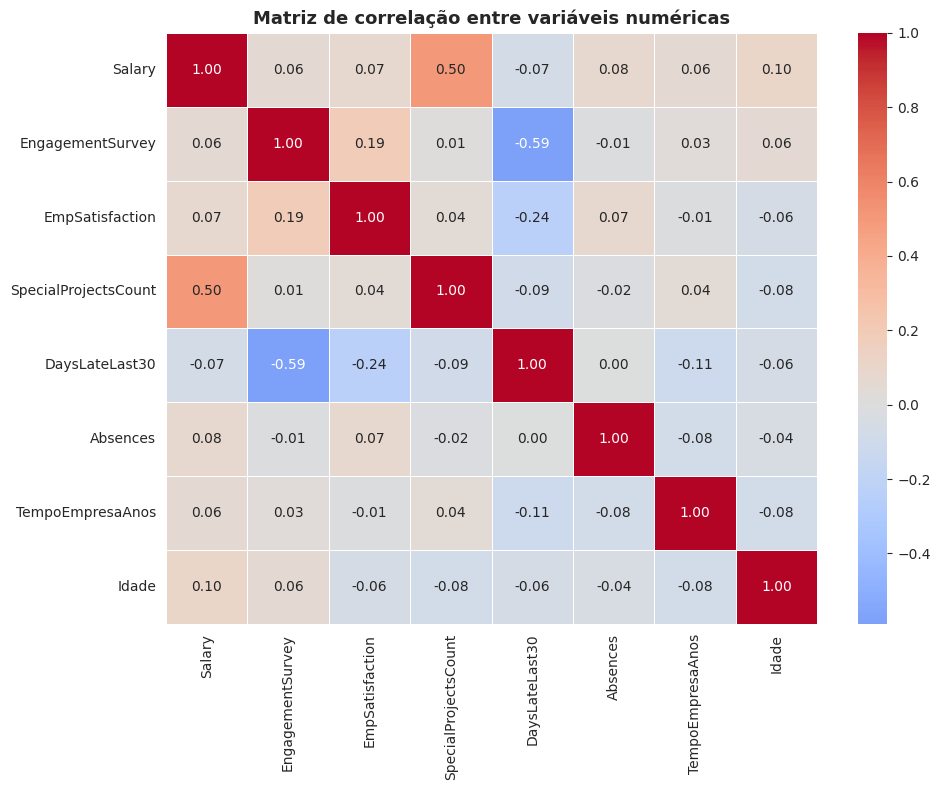

In [74]:
plt.figure(figsize=(10, 8))
sns.heatmap(matriz_correlacao, annot=True, cmap="coolwarm", center=0, fmt=".2f", linewidths=0.5)
plt.title("Matriz de correlação entre variáveis numéricas")
plt.tight_layout()
plt.show()

A correlação mais forte da matriz é entre `Salary` e `SpecialProjectsCount`, confirmando o que já havia sido observado na análise de projetos especiais. Também há uma correlação negativa relevante entre `EngagementSurvey` e `DaysLateLast30`, sugerindo que funcionários mais engajados tendem a se atrasar menos.

As demais variáveis apresentam correlações fracas entre si, o que indica que fatores como satisfação, idade e tempo de empresa não têm uma relação linear forte com salário ou desempenho nesta base.

## Relações importantes

### Salário x Performance

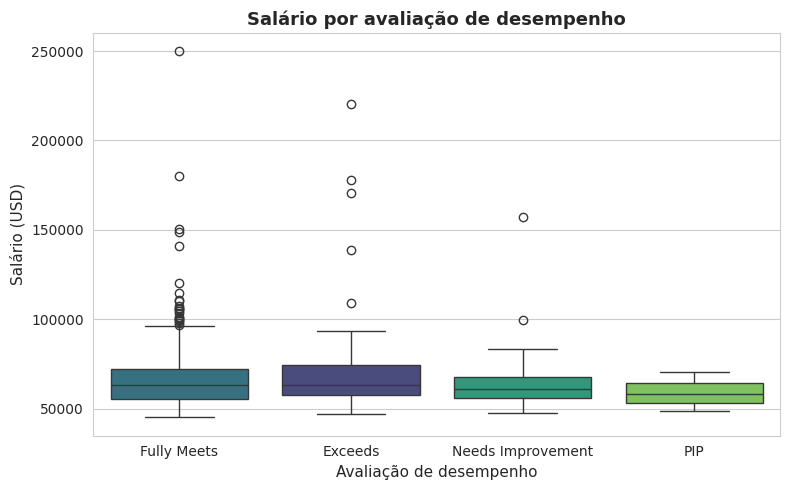

In [75]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="PerformanceScore", y="Salary", order=ordem_performance, hue="PerformanceScore", palette=paleta, legend=False)
plt.title("Salário por avaliação de desempenho")
plt.xlabel("Avaliação de desempenho")
plt.ylabel("Salário (USD)")
plt.tight_layout()
plt.show()

### Salário x Satisfação

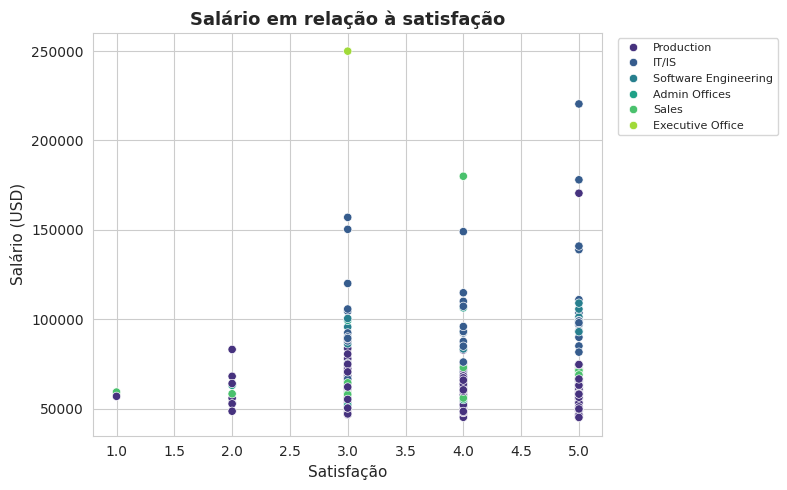

In [76]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="EmpSatisfaction", y="Salary", hue="Department", palette=paleta)
plt.title("Salário em relação à satisfação")
plt.xlabel("Satisfação")
plt.ylabel("Salário (USD)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

### Performance x Satisfação

In [1]:
plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x="PerformanceScore", y="EmpSatisfaction", order=ordem_performance, hue="PerformanceScore", palette=paleta, legend=False)
plt.title("Satisfação por avaliação de desempenho")
plt.xlabel("Avaliação de desempenho")
plt.ylabel("Satisfação")
plt.tight_layout()
plt.show()

NameError: name 'plt' is not defined

### Engajamento x Performance

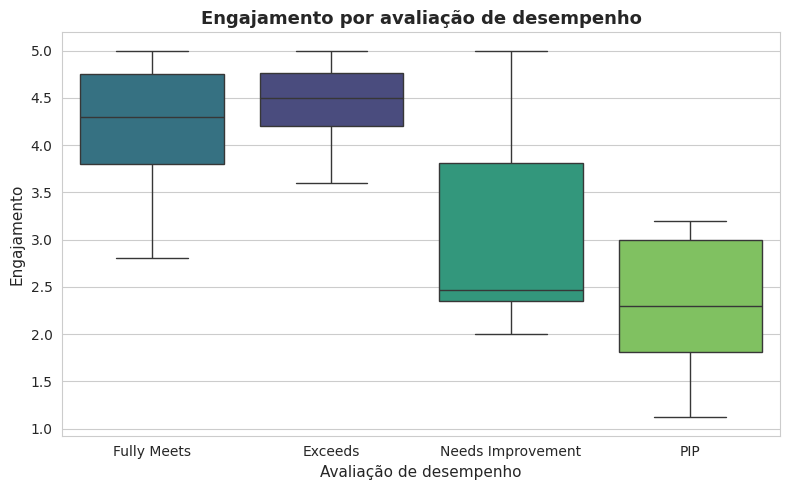

In [78]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="PerformanceScore", y="EngagementSurvey", order=ordem_performance, hue="PerformanceScore", palette=paleta, legend=False)
plt.title("Engajamento por avaliação de desempenho")
plt.xlabel("Avaliação de desempenho")
plt.ylabel("Engajamento")
plt.tight_layout()
plt.show()

### Engajamento x Salário

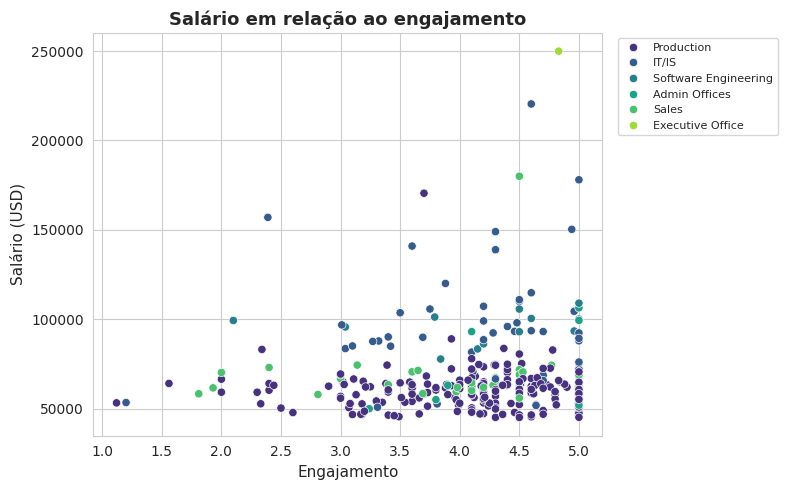

In [79]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="EngagementSurvey", y="Salary", hue="Department", palette=paleta)
plt.title("Salário em relação ao engajamento")
plt.xlabel("Engajamento")
plt.ylabel("Salário (USD)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

### Atrasos x Performance

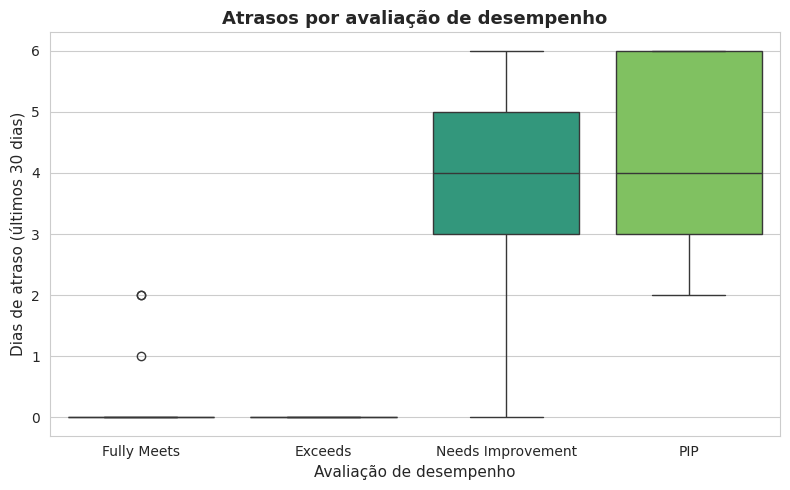

In [80]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="PerformanceScore", y="DaysLateLast30", order=ordem_performance, hue="PerformanceScore", palette=paleta, legend=False)
plt.title("Atrasos por avaliação de desempenho")
plt.xlabel("Avaliação de desempenho")
plt.ylabel("Dias de atraso (últimos 30 dias)")
plt.tight_layout()
plt.show()

### Faltas x Performance

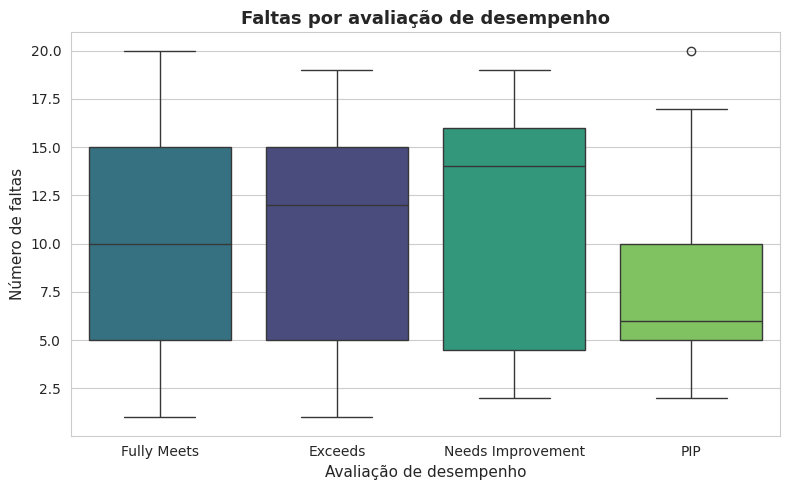

In [81]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="PerformanceScore", y="Absences", order=ordem_performance, hue="PerformanceScore", palette=paleta, legend=False)
plt.title("Faltas por avaliação de desempenho")
plt.xlabel("Avaliação de desempenho")
plt.ylabel("Número de faltas")
plt.tight_layout()
plt.show()

O salário não varia de forma relevante entre as faixas de performance, reforçando que a remuneração está mais ligada ao cargo do que à avaliação recente. A satisfação e o engajamento seguem padrão parecido entre as categorias, com leve queda na faixa "PIP".

Atrasos e faltas não mostram uma relação direta e consistente com performance, o que indica que o absenteísmo, isoladamente, não é um bom previsor da avaliação de desempenho dos funcionários desta base.

## Conclusão

A análise da base de Recursos Humanos mostrou uma empresa com 310 funcionários, turnover geral de aproximadamente 33% e salário médio próximo de 69 mil dólares. Production e Software Engineering concentram a maior rotatividade, enquanto Executive Office se destaca pela estabilidade e pelos maiores salários.

Os indicadores de satisfação e engajamento são relativamente homogêneos entre departamentos, sem um setor crítico evidente. A participação em projetos especiais aparece como o fator mais associado a salários mais altos e melhores avaliações de desempenho, o que pode indicar tanto seleção de bons profissionais para esses projetos quanto um ganho de performance gerado por eles.

De forma geral, os dados sugerem que ações de retenção poderiam ser direcionadas especialmente para os departamentos de Production e Software Engineering, e que a expansão de projetos especiais pode ser uma alavanca interessante para impulsionar performance e remuneração dos times.